# AIRLINE PASSENGER SATISFACTION 

This dataset contains an airline passenger satisfaction survey.

# *Objectives*

We will try to answer the following questions.
1. What factors are highly correlated to a satisfied (or dissatisfied) passenger? 
2. Which services have the greatest impact on passenger satisfaction?
3. Can you predict passenger satisfaction?



## Import the modules required as their alias respectively

In [34]:
# import the modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#  Load the file


In [35]:
df = pd.read_csv('train.csv', index_col=0)
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [36]:
df.tail()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
103899,94171,Female,disloyal Customer,23,Business travel,Eco,192,2,1,2,...,2,3,1,4,2,3,2,3,0.0,neutral or dissatisfied
103900,73097,Male,Loyal Customer,49,Business travel,Business,2347,4,4,4,...,5,5,5,5,5,5,4,0,0.0,satisfied
103901,68825,Male,disloyal Customer,30,Business travel,Business,1995,1,1,1,...,4,3,2,4,5,5,4,7,14.0,neutral or dissatisfied
103902,54173,Female,disloyal Customer,22,Business travel,Eco,1000,1,1,1,...,1,4,5,1,5,4,1,0,0.0,neutral or dissatisfied
103903,62567,Male,Loyal Customer,27,Business travel,Business,1723,1,3,3,...,1,1,1,4,4,3,1,0,0.0,neutral or dissatisfied


## Explore the data

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     1039

In [38]:
# check the columns in the dataset
df.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

## Check for duplicates and unwanted observations

In [39]:
# check for duplicated values
df.duplicated()


0         False
1         False
2         False
3         False
4         False
          ...  
103899    False
103900    False
103901    False
103902    False
103903    False
Length: 103904, dtype: bool

In [40]:
#check if there are any duplicated values in the dataset
df.duplicated().any()

False

## Handling Missing Values

In [41]:
#check for missing values
df.isnull().any()

id                                   False
Gender                               False
Customer Type                        False
Age                                  False
Type of Travel                       False
Class                                False
Flight Distance                      False
Inflight wifi service                False
Departure/Arrival time convenient    False
Ease of Online booking               False
Gate location                        False
Food and drink                       False
Online boarding                      False
Seat comfort                         False
Inflight entertainment               False
On-board service                     False
Leg room service                     False
Baggage handling                     False
Checkin service                      False
Inflight service                     False
Cleanliness                          False
Departure Delay in Minutes           False
Arrival Delay in Minutes              True
satisfactio

In [42]:
# count the number of missing values in each column
df.isnull().sum()

# sort the missing values in descending order
df.isnull().sum().sort_values(ascending=False)

Arrival Delay in Minutes             310
id                                     0
Gender                                 0
Departure Delay in Minutes             0
Cleanliness                            0
Inflight service                       0
Checkin service                        0
Baggage handling                       0
Leg room service                       0
On-board service                       0
Inflight entertainment                 0
Seat comfort                           0
Online boarding                        0
Food and drink                         0
Gate location                          0
Ease of Online booking                 0
Departure/Arrival time convenient      0
Inflight wifi service                  0
Flight Distance                        0
Class                                  0
Type of Travel                         0
Age                                    0
Customer Type                          0
satisfaction                           0
dtype: int64

In [43]:
# check the number of unique values in each column
df.nunique()

id                                   103904
Gender                                    2
Customer Type                             2
Age                                      75
Type of Travel                            2
Class                                     3
Flight Distance                        3802
Inflight wifi service                     6
Departure/Arrival time convenient         6
Ease of Online booking                    6
Gate location                             6
Food and drink                            6
Online boarding                           6
Seat comfort                              6
Inflight entertainment                    6
On-board service                          6
Leg room service                          6
Baggage handling                          5
Checkin service                           6
Inflight service                          6
Cleanliness                               6
Departure Delay in Minutes              446
Arrival Delay in Minutes        

In [44]:
#calculate the percentage of missing values
missing_values = np.round(((df.isnull().sum() / len(df)) * 100), 2)
missing_values

id                                   0.0
Gender                               0.0
Customer Type                        0.0
Age                                  0.0
Type of Travel                       0.0
Class                                0.0
Flight Distance                      0.0
Inflight wifi service                0.0
Departure/Arrival time convenient    0.0
Ease of Online booking               0.0
Gate location                        0.0
Food and drink                       0.0
Online boarding                      0.0
Seat comfort                         0.0
Inflight entertainment               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                     0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                          0.0
Departure Delay in Minutes           0.0
Arrival Delay in Minutes             0.3
satisfaction                         0.0
dtype: float64

In [45]:
df['Arrival Delay in Minutes']

0         18.0
1          6.0
2          0.0
3          9.0
4          0.0
          ... 
103899     0.0
103900     0.0
103901    14.0
103902     0.0
103903     0.0
Name: Arrival Delay in Minutes, Length: 103904, dtype: float64

In [46]:
#forward fill the missing values
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean())


In [47]:
# confirm if the missing values have been filled
df['Arrival Delay in Minutes'].isnull().sum()

0

### *Explore the factors that correlate with Satisfaction*

In [48]:
df.corr()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
id,1.000000,0.022857,0.095544,-0.021276,-0.002110,0.014163,-0.000606,0.001063,0.055477,0.052903,0.002300,0.055241,0.044634,0.074940,0.079273,0.079346,0.024965,-0.019546,-0.037196
Age,0.022857,1.000000,0.099461,0.017859,0.038125,0.024842,-0.001330,0.023000,0.208939,0.160277,0.076444,0.057594,0.040583,-0.047529,0.035482,-0.049427,0.053611,-0.010152,-0.012127
Flight Distance,0.095544,0.099461,1.000000,0.007131,-0.020043,0.065717,0.004793,0.056994,0.214869,0.157333,0.128740,0.109526,0.133916,0.063184,0.073072,0.057540,0.093149,0.002158,-0.002423
Inflight wifi service,-0.021276,0.017859,0.007131,1.000000,0.343845,0.715856,0.336248,0.134718,0.456970,0.122658,0.209321,0.121500,0.160473,0.120923,0.043193,0.110441,0.132698,-0.017402,-0.019067
Departure/Arrival time convenient,-0.002110,0.038125,-0.020043,0.343845,1.000000,0.436961,0.444757,0.004906,0.070119,0.011344,-0.004861,0.068882,0.012441,0.072126,0.093333,0.073318,0.014292,0.001005,-0.000863
Ease of Online booking,0.014163,0.024842,0.065717,0.715856,0.436961,1.000000,0.458655,0.031873,0.404074,0.030014,0.047032,0.038833,0.107601,0.038762,0.011081,0.035272,0.016179,-0.006371,-0.007972
Gate location,-0.000606,-0.001330,0.004793,0.336248,0.444757,0.458655,1.000000,-0.001159,0.001688,0.003669,0.003517,-0.028373,-0.005873,0.002313,-0.035427,0.001681,-0.003830,0.005467,0.005136
Food and drink,0.001063,0.023000,0.056994,0.134718,0.004906,0.031873,-0.001159,1.000000,0.234468,0.574556,0.622512,0.059073,0.032498,0.034746,0.087299,0.033993,0.657760,-0.029926,-0.032472
Online boarding,0.055477,0.208939,0.214869,0.456970,0.070119,0.404074,0.001688,0.234468,1.000000,0.420211,0.285066,0.155443,0.123950,0.083280,0.204462,0.074573,0.331517,-0.018982,-0.021915
Seat comfort,0.052903,0.160277,0.157333,0.122658,0.011344,0.030014,0.003669,0.574556,0.420211,1.000000,0.610590,0.131971,0.105559,0.074542,0.191854,0.069218,0.678534,-0.027898,-0.029851


 From the above table we can find that Departure Delay in MInutes is highly correlated with satisfaction and therefore a major cause of dissatisfaction

## DATA VISUALIZATION

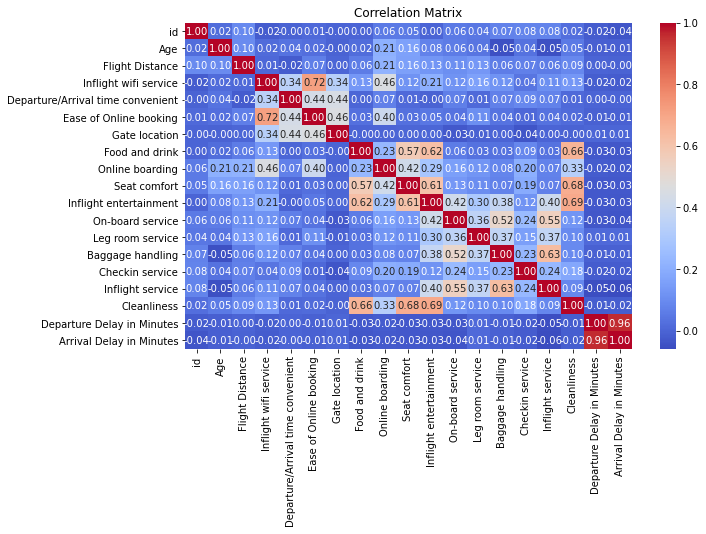

<Figure size 432x288 with 0 Axes>

In [49]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', cbar=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# save the figure
plt.savefig('correlation_matrix.png')


### Inspect any outliers in the data set

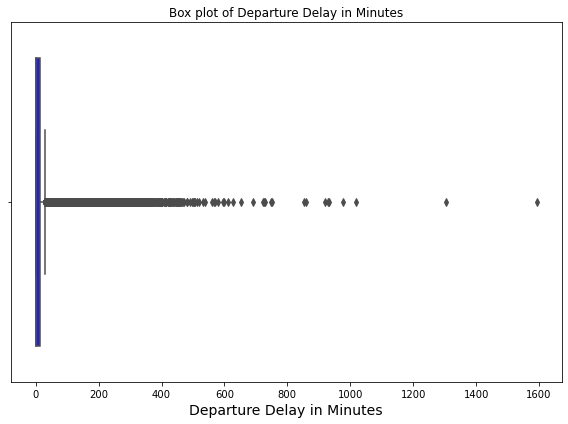

In [50]:
# plot a box plot of the `Departure Delay in Minutes` column
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Departure Delay in Minutes'], orient='h', color='blue')
plt.xlabel('Departure Delay in Minutes', fontsize=14)
plt.title('Box plot of Departure Delay in Minutes')

plt.tight_layout()
plt.show()


* The above plot indicates skewness to the right due extreme values(outliers)
* These outliers hinder our visualization therefore we have to remove them 

Import additional modules

In [51]:
import os
from scipy import stats
from scipy.stats import norm
from matplotlib.cbook import boxplot_stats

In [52]:
stat = boxplot_stats(df['Departure Delay in Minutes'])
stat

[{'mean': 14.815618263012011,
  'iqr': 12.0,
  'cilo': -0.05844734191582151,
  'cihi': 0.05844734191582151,
  'whishi': 30,
  'whislo': 0,
  'fliers': array([ 43,  49,  52, ...,  47,  35, 110]),
  'q1': 0.0,
  'med': 0.0,
  'q3': 12.0}]

In [53]:
q1 = df['Departure Delay in Minutes'].quantile(0.25) # first quartile value
q3 = df['Departure Delay in Minutes'].quantile(0.75) # third quartile value

iqr = q3 - q1 # interquartile range

# outliers
outliers = ((df['Departure Delay in Minutes'] < (q1 - 1.5 * iqr)) | (df['Departure Delay in Minutes'] > (q3 + 1.5 * iqr))) 
outliers

0         False
1         False
2         False
3         False
4         False
          ...  
103899    False
103900    False
103901    False
103902    False
103903    False
Name: Departure Delay in Minutes, Length: 103904, dtype: bool

In [54]:
# number of outliers
outliers_list = list(outliers[outliers == True].index)
df.loc[outliers_list]

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
14,95789,Female,Loyal Customer,26,Personal Travel,Eco,453,3,2,3,...,2,4,3,2,2,1,2,43,35.0,neutral or dissatisfied
16,71142,Female,Loyal Customer,26,Business travel,Business,2123,3,3,3,...,4,5,3,4,5,4,4,49,51.0,satisfied
22,43510,Female,Loyal Customer,43,Personal Travel,Eco,752,3,5,3,...,3,3,3,5,3,3,4,52,29.0,neutral or dissatisfied
24,105420,Female,disloyal Customer,23,Business travel,Eco,452,5,0,5,...,1,4,5,5,3,5,1,54,44.0,satisfied
32,70594,Female,Loyal Customer,35,Business travel,Business,2611,4,5,4,...,3,3,4,5,4,3,4,109,120.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103869,55713,Male,Loyal Customer,18,Personal Travel,Eco,895,4,5,4,...,3,5,4,5,1,3,1,212,206.0,neutral or dissatisfied
103881,9345,Female,Loyal Customer,51,Business travel,Business,384,2,2,2,...,4,4,4,4,3,4,3,54,51.0,satisfied
103885,122528,Male,Loyal Customer,40,Business travel,Business,500,4,4,4,...,3,3,3,3,5,3,4,47,26.0,satisfied
103891,83013,Male,Loyal Customer,54,Business travel,Business,1991,5,5,5,...,4,4,5,4,5,4,4,35,31.0,satisfied


# *plot a bar chart of departure delay in minutes against satisfaction*

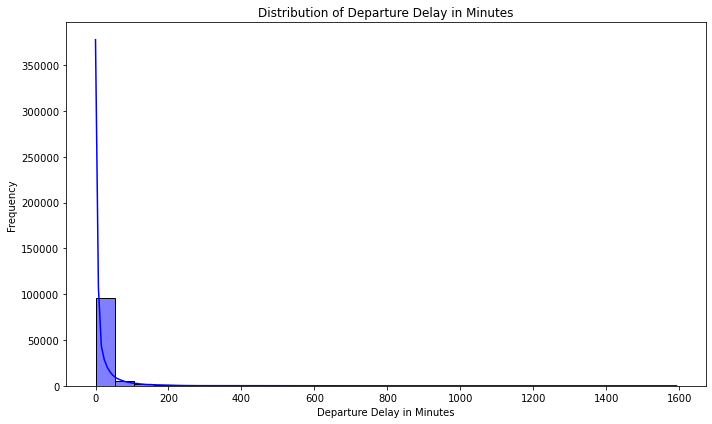

In [55]:
# plot the distribution of the `Departure Delay in Minutes` column
plt.figure(figsize=(10, 6)) 
sns.histplot(df['Departure Delay in Minutes'], kde=True, color='blue', bins=30)
plt.title('Distribution of Departure Delay in Minutes')
plt.xlabel('Departure Delay in Minutes')
plt.ylabel('Frequency')
plt.tight_layout()  
plt.show()


<Figure size 720x432 with 0 Axes>

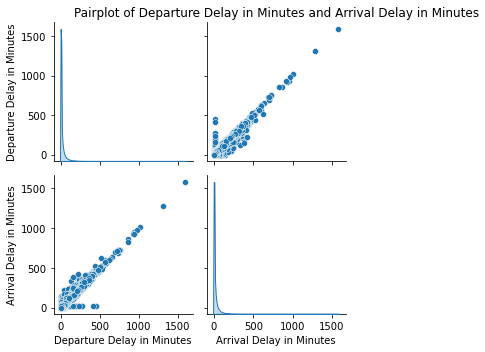

In [56]:
cols = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']
plt.figure(figsize=(10, 6))
sns.pairplot(df[cols], kind='scatter', diag_kind='kde')
plt.title('Pairplot of Departure Delay in Minutes and Arrival Delay in Minutes')
plt.tight_layout()
plt.show()


* From the plot above we can see that many points are clustered near the zero in both diagrams which means many flights depart and arrive close to on time.

* The bottom-left scatter plot indicate a strong positive correlation between departure and arrival delays > meaning as the departure delay increases the arrival also increases.

* From the histograms there are small delays to very large delays.

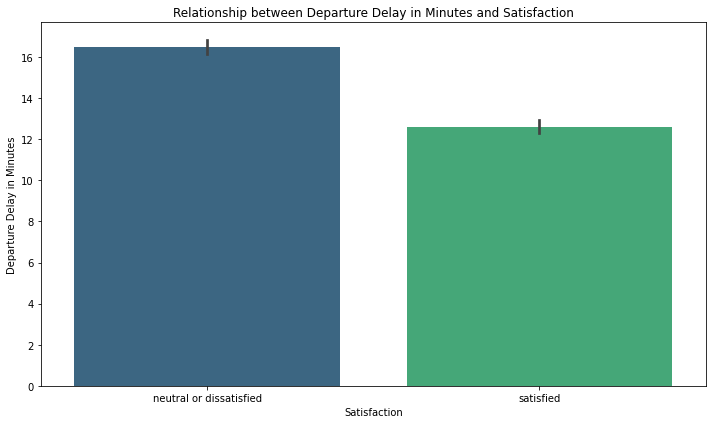

<Figure size 432x288 with 0 Axes>

In [58]:
# plot the relationship between 'Departure Delay in Minutes' and 'satisfaction'
plt.figure(figsize=(10, 6))
sns.barplot(x='satisfaction', y='Departure Delay in Minutes', data=df, palette='viridis' )
plt.title('Relationship between Departure Delay in Minutes and Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Departure Delay in Minutes')
plt.tight_layout()
plt.show()

# save the figure
plt.savefig('departure_delay_satisfaction.png')

* As shown above, increased departure delays increased dissatisfaction

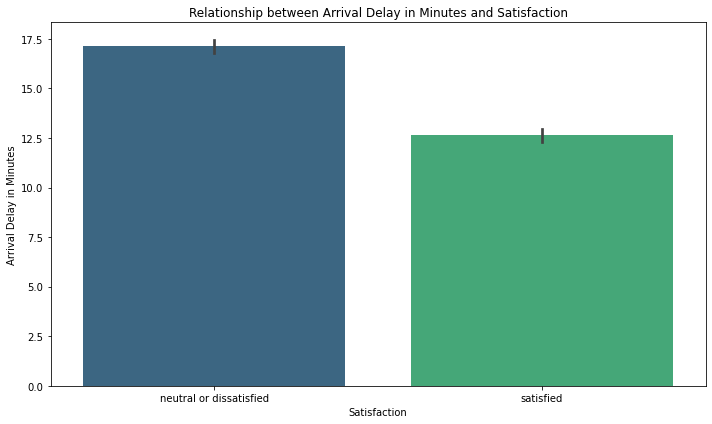

In [ ]:
# plot the relationship between 'Arrival Delay in Minutes' and 'satisfaction'
plt.figure(figsize=(10, 6))
sns.barplot(x='satisfaction', y='Arrival Delay in Minutes', data=df, palette='viridis')
plt.title('Relationship between Arrival Delay in Minutes and Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Arrival Delay in Minutes')
plt.tight_layout()
plt.show()


* Again in this bar graph, increased arrival delays led to increased dissatisfaction and vice versa

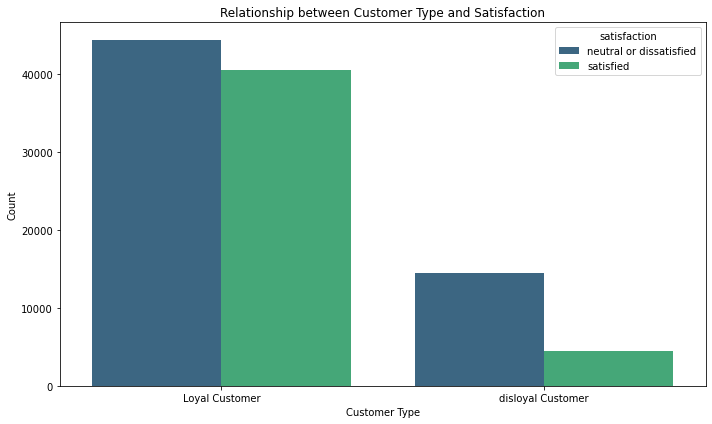

In [ ]:
# plot the relationship between 'Customer type' and 'satisfaction'
plt.figure(figsize=(10, 6))
sns.countplot(x='Customer Type', hue='satisfaction', data=df, palette='viridis')
plt.title('Relationship between Customer Type and Satisfaction')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


* This indicates a great number of loyal customers dissatisfied as well as very low satisafaction to disloyal customers.


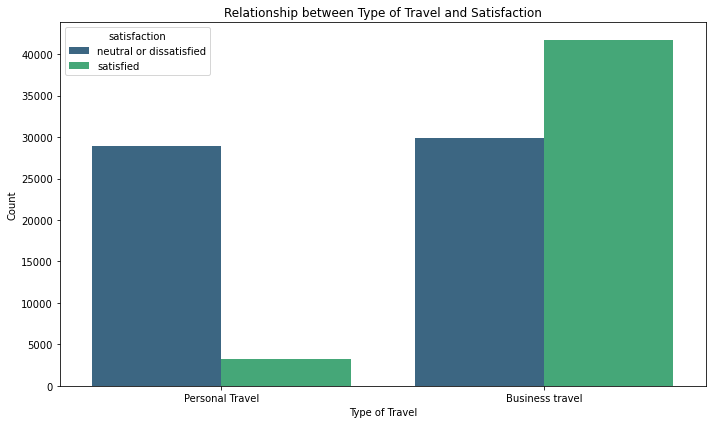

In [ ]:
# plot the relationship between 'Type of Travel' and 'satisfaction'
plt.figure(figsize=(10, 6))
sns.countplot(x='Type of Travel', hue='satisfaction', data=df, palette='viridis')
plt.title('Relationship between Type of Travel and Satisfaction')
plt.xlabel('Type of Travel')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


* More passengers on business travel were satisfied than those on personal travel

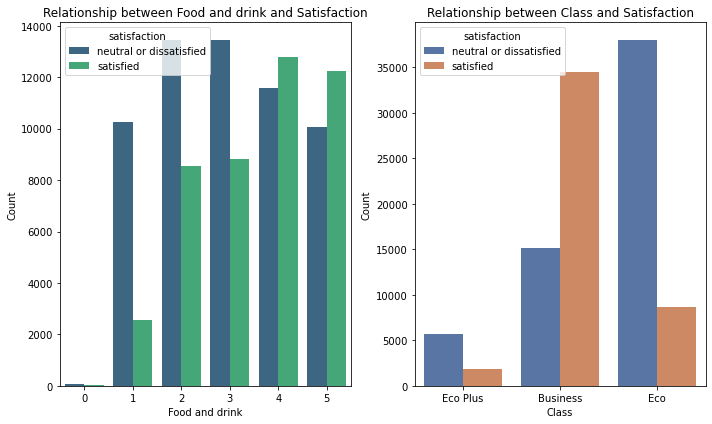

In [ ]:
# plot the relationship between 'Class', 'food and drink' and 'satisfaction'
fig, ax = plt.subplots(1, 2 ,figsize=(10, 6))
sns.countplot(x= 'Food and drink', hue='satisfaction', data=df, palette='viridis', ax=ax[0])
ax[0].set_title('Relationship between Food and drink and Satisfaction')
ax[0].set_xlabel('Food and drink')
ax[0].set_ylabel('Count')


sns.countplot(x='Class', hue='satisfaction', data=df, palette='deep', ax=ax[1])
ax[1].set_title('Relationship between Class and Satisfaction')
ax[1].set_xlabel('Class')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()


* In the food and drink plot we can draw that there is high dissatisfaction across columns.
* In the class as well the eco class has higher values of dissatisfaction than the Eco PLus, Business class have more satisfied travellers .
 

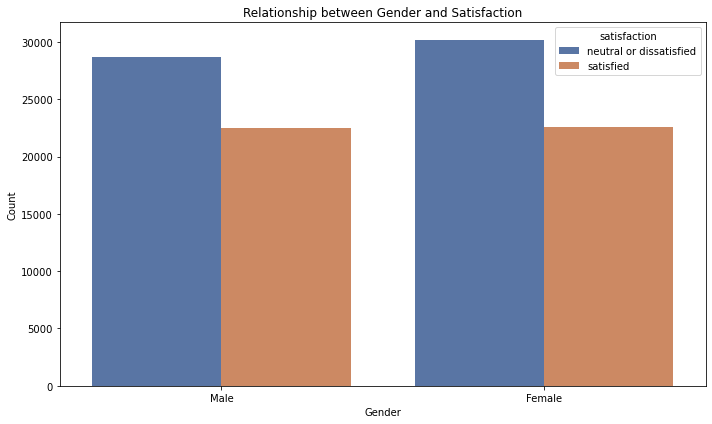

In [ ]:
# plot the relation between 'Gender' and 'satisfaction'
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(x= 'Gender', hue='satisfaction', data=df, palette='deep', ax=ax)
plt.title('Relationship between Gender and Satisfaction')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

* In both gender column there is slightly higher dissatisfaction than satisfaction

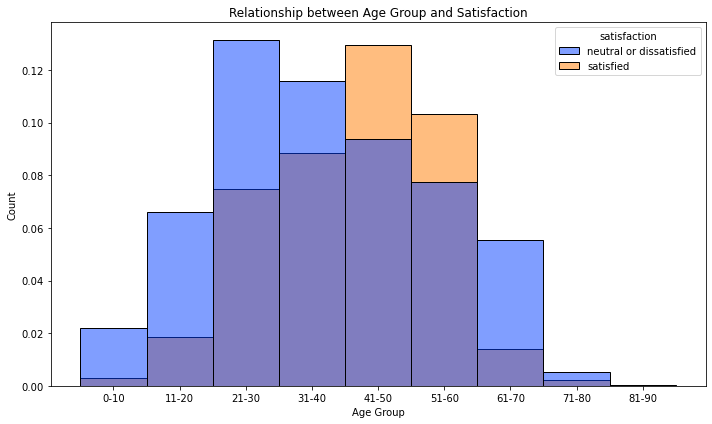

In [71]:
# plot the relationship between 'Age' and 'satisfaction'
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.histplot(x='AgeGroup', hue='satisfaction', data=df, palette='bright', bins=bins, stat= 'probability')
plt.title('Relationship between Age Group and Satisfaction')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


* There is a significant dissatisfaction in young age groups than the older ones. 


In [72]:
# find the percentage of satisfied and unsatisfied customers
satisfied = df['satisfaction'].value_counts(normalize=True) * 100
satisfied

neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: satisfaction, dtype: float64

## Summary

### We have seen that different there are factors that affect the satisfaction of airline travellers.
The main drivers of customer dissatisfaction are: Departure delay and arrival delay


 